# Transmission lines and coaxial cables

PyOR Python On Resonance

Author: Vineeth Francis Thalakottoor Jose Chacko

Three independent examples: a two-port line, a one-port line with its far end open, and a one-port line with its far end shorted to P0. Each example uses `Element(..., "TL", ...)` and can be tuned independently.

Use PyOR_RF_Circuits v1_11 or later, installed as `PyORv2/PyOR_RF_Circuits.py`. Keep the usual PyOR import. If widgets are missing, run `%pip install ipywidgets` in a notebook cell, then restart the kernel.


In [1]:
# Define the source path
SourcePath = "/home/vineeth/Documents/PyOR/PyOR"

# Add source path
import sys
sys.path.append(SourcePath)

import time
%matplotlib inline

# Import PyOR package
from PyORv2 import *


*****        ***** *****
*   *        *   * *   *
*****  *   * *   * *****
*       * *  *   * * *  
*        *   ***** *  * 
        *               
       *                
Welcome to Python On Resonance (PyOR)

"In everlasting memory of Gauri, who led me from untruth to Truth, from darkness to Light, and from death to Immortality."

Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay

Email: vineeth.thalakottoor@cea.fr

"Everybody can simulate Magnetic Resonance"

Imported modules:

* QuantumSystem          (QuantumSystem from PyOR_QuantumSystem - for single quantum system)
* QuantumSystems         (QuantumSystems from PyOR_QuantumSystems - for multiple quantum systems)
** Hamiltonian           (from PyOR_Hamiltonian)
** DensityMatrix         (from PyOR_DensityMatrix)
** HardPulse             (from PyOR_HardPulse)
** Basis                 (from PyOR_Basis)
** RelaxationProcess     (from PyOR_Relaxation)
** Evolutions            (from PyOR_Evolution)
** Plotting          

## Line parameters and ground

| Setting | Meaning |
| --- | --- |
| Reference_Impedance | Measurement-port reference impedance, in ohms |
| Characteristic_Impedance | Cable characteristic impedance, in ohms |
| Line_Length and Length_Unit | Physical cable length: mm, cm or m |
| Velocity_Factor | Propagation velocity divided by the speed of light |
| epsilon_r | Alternative to velocity factor; use one of these inputs |
| Attenuation_dB_Per_m | Constant attenuation per metre; zero is lossless |

The line has two **signal endpoints** and an implicit common shield/return **P0**. Each measurement port is referenced to P0. This is a common-ground TEM line model; it does not represent independent floating shields.

The default line impedance is 75 ohms and the port reference is 50 ohms, making the two-port reflections visible. Set Characteristic_Impedance to 50 for a matched line. VF and dielectric sliders are linked; characteristic impedance is tuned separately.


In [2]:
Reference_Impedance = 50.0
Characteristic_Impedance = 50.0
Line_Length = 150.0
Length_Unit = "cm"
Velocity_Factor = 0.66
Attenuation_dB_Per_m = 0.0

Frequency_Start = "1MHz"
Frequency_Stop = "550MHz"
Frequency_Limits = (1, 550)  # MHz
Sweep_Points = 5001


## 1. Two-port transmission line

P1 measures N1 relative to P0, and P2 measures N2 relative to P0. For S11, the simulator terminates P2 in Reference_Impedance; for S22, it terminates P1 in Reference_Impedance. A measurement port is a terminated measurement boundary, so P2 is not an open circuit.

| Port | Signal node | Reference |
| --- | --- | --- |
| P1 | N1 | P0 |
| P2 | N2 | P0 |


Two-port transmission line; common ground P0
Port 1 (P1) -> node N1; reference node P0
Port 2 (P2) -> node N2; reference node P0
All electrical nodes: ['N1', 'N2']
Reference impedance: 50.0 Ω


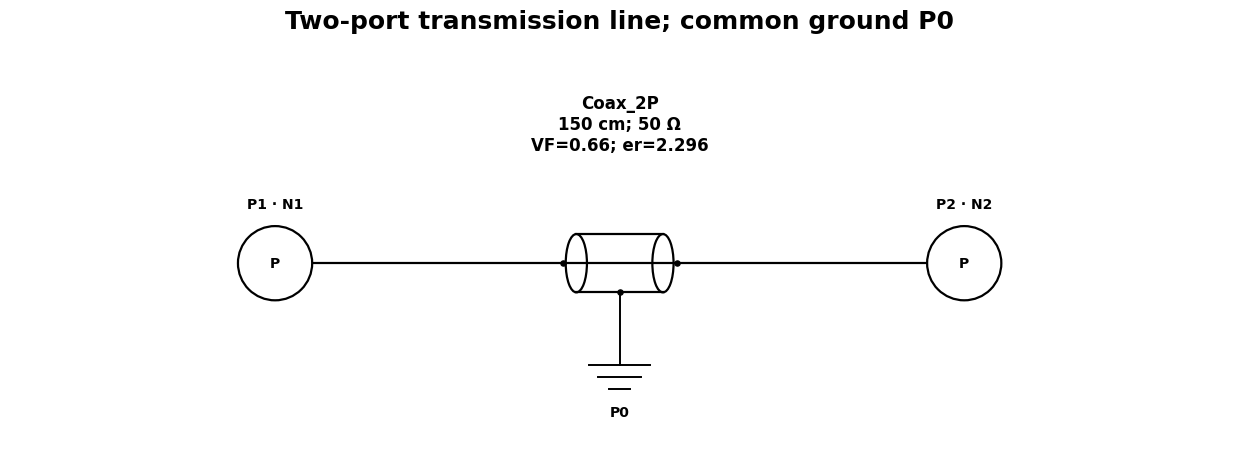

In [3]:
two_port_components = [
    Element("Coax_2P", "TL", "N1", "N2", Line_Length, Length_Unit,
            z0=Characteristic_Impedance,
            velocity_factor=Velocity_Factor,
            attenuation_db_per_m=Attenuation_dB_Per_m),
]
two_port_ports = [("P1", "N1"), ("P2", "N2")]

two_port_circuit = RFCircuit(
    two_port_components, two_port_ports,
    z0=Reference_Impedance,
    title="Two-port transmission line; common ground P0",
)
two_port_circuit.Plot_Circuit(figsize=(14, 5))


In [4]:
two_port_frequency, two_port_S = two_port_circuit.Simulate(
    start=Frequency_Start, stop=Frequency_Stop,
    points=Sweep_Points, logarithmic=False, refine=False,
)


5,001 frequency samples; S shape = (5001, 2, 2)


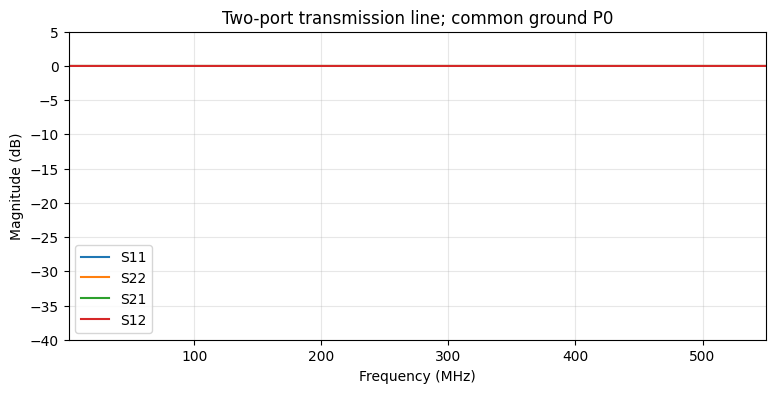

In [5]:
_ = two_port_circuit.Plot_Sparameter(
    ["S11", "S22", "S21", "S12"],
    xlim=Frequency_Limits, ylim=(-40, 5),
)


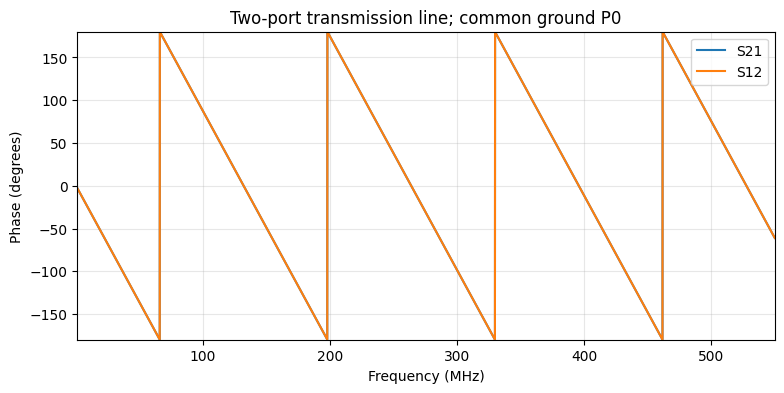

In [6]:
_ = two_port_circuit.Plot_Sparameter(
    ["S21", "S12"], phase=True, xlim=Frequency_Limits,
)


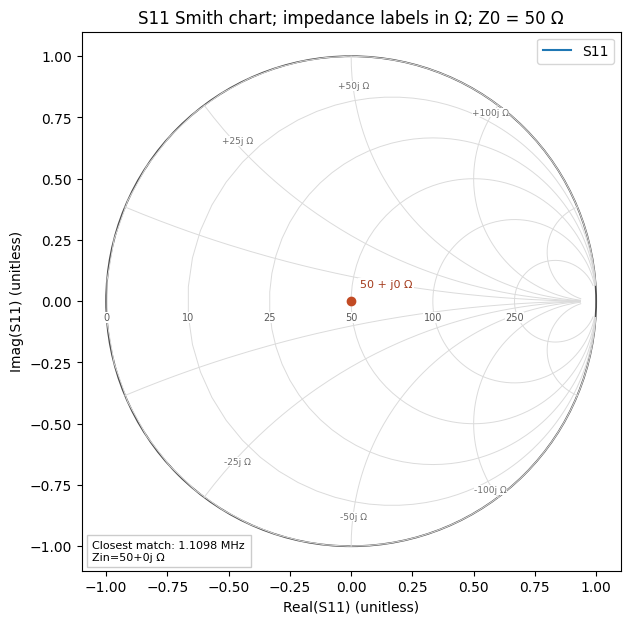

In [7]:
_ = two_port_circuit.Plot_Smith("S11")


In [8]:
two_port_panel = two_port_circuit.Plot_Interactive(
    ["S11", "S22", "S21", "S12"],
    xlim=Frequency_Limits, ylim=(-40, 5),
    points=Sweep_Points, refine=False,
    markers=(150, 180),
)


## 2. One-port transmission line: far end open

Only P1 is defined. N_open is the far-end signal node and has no load or measurement port connected to it. Its line terminal current is therefore zero. The shield remains connected to P0.

Do not add P2 at N_open: that would terminate the far end in the port reference impedance instead of leaving it open.


One-port transmission line; far end N_open is open; shield P0
Port 1 (P1) -> node N1; reference node P0
All electrical nodes: ['N1', 'N_open']
Reference impedance: 50.0 Ω


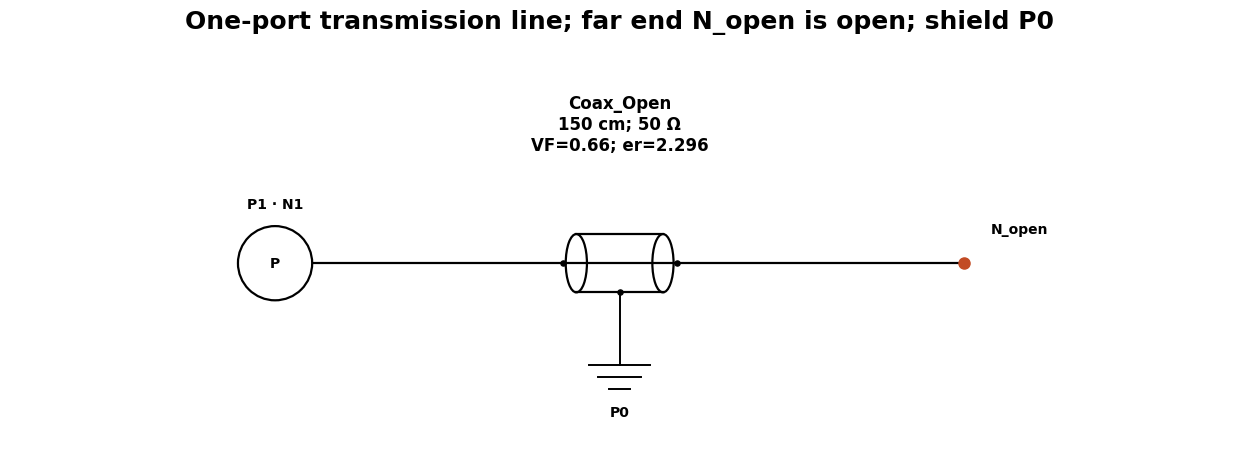

In [9]:
open_components = [
    Element("Coax_Open", "TL", "N1", "N_open", Line_Length, Length_Unit,
            z0=Characteristic_Impedance,
            velocity_factor=Velocity_Factor,
            attenuation_db_per_m=Attenuation_dB_Per_m),
]
open_ports = [("P1", "N1")]

open_circuit = RFCircuit(
    open_components, open_ports,
    z0=Reference_Impedance,
    title="One-port transmission line; far end N_open is open; shield P0",
)
open_circuit.Plot_Circuit(figsize=(14, 5))


In [10]:
open_frequency, open_S = open_circuit.Simulate(
    start=Frequency_Start, stop=Frequency_Stop,
    points=Sweep_Points, logarithmic=False, refine=False,
)


5,001 frequency samples; S shape = (5001, 1, 1)


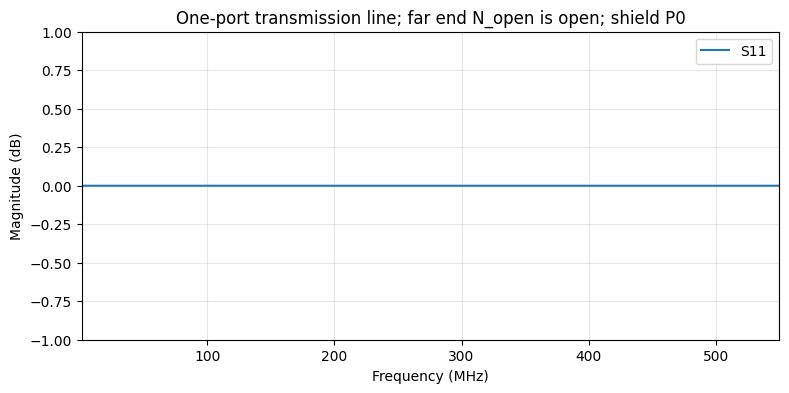

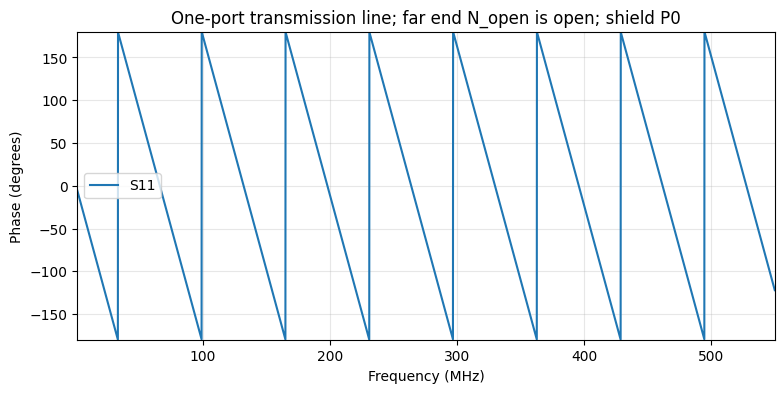

In [11]:
_ = open_circuit.Plot_Sparameter(
    "S11", xlim=Frequency_Limits, ylim=(-1, 1),
)
_ = open_circuit.Plot_Sparameter(
    "S11", phase=True, xlim=Frequency_Limits,
)


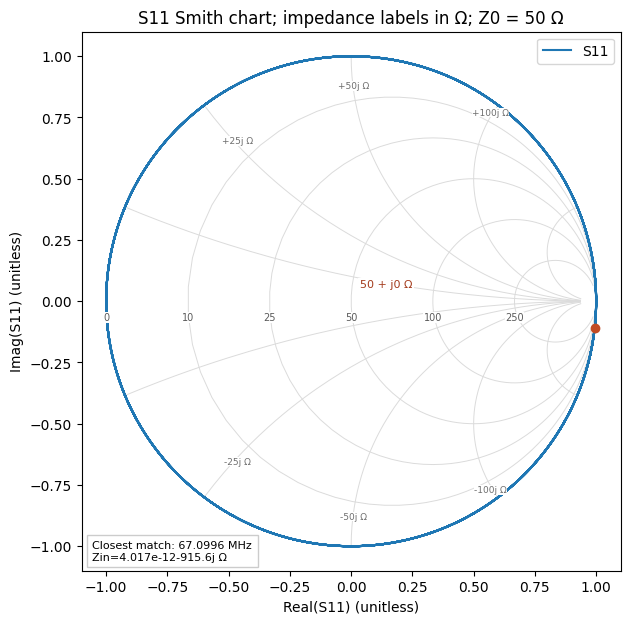

In [12]:
_ = open_circuit.Plot_Smith("S11")


In [13]:
open_panel = open_circuit.Plot_Interactive(
    ["S11"], xlim=Frequency_Limits, ylim=(-1, 1),
    points=Sweep_Points, refine=False,
    markers=(150, 180),
)


## 3. One-port transmission line: far end shorted

Only P1 is defined. The far-end signal conductor is connected directly to P0, shorting it to the shield. The short is made by the endpoint node, so no zero-ohm resistor is needed.


One-port transmission line; far end shorted to P0
Port 1 (P1) -> node N1; reference node P0
All electrical nodes: ['N1', 'P0']
Reference impedance: 50.0 Ω


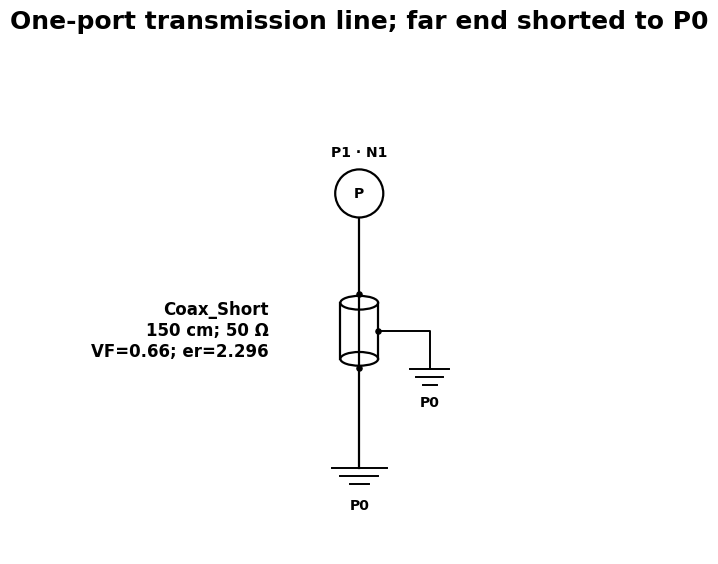

In [14]:
short_components = [
    Element("Coax_Short", "TL", "N1", "P0", Line_Length, Length_Unit,
            z0=Characteristic_Impedance,
            velocity_factor=Velocity_Factor,
            attenuation_db_per_m=Attenuation_dB_Per_m),
]
short_ports = [("P1", "N1")]

short_circuit = RFCircuit(
    short_components, short_ports,
    z0=Reference_Impedance,
    title="One-port transmission line; far end shorted to P0",
)
short_circuit.Plot_Circuit(figsize=(14, 6))


In [15]:
short_frequency, short_S = short_circuit.Simulate(
    start=Frequency_Start, stop=Frequency_Stop,
    points=Sweep_Points, logarithmic=False, refine=False,
)


5,001 frequency samples; S shape = (5001, 1, 1)


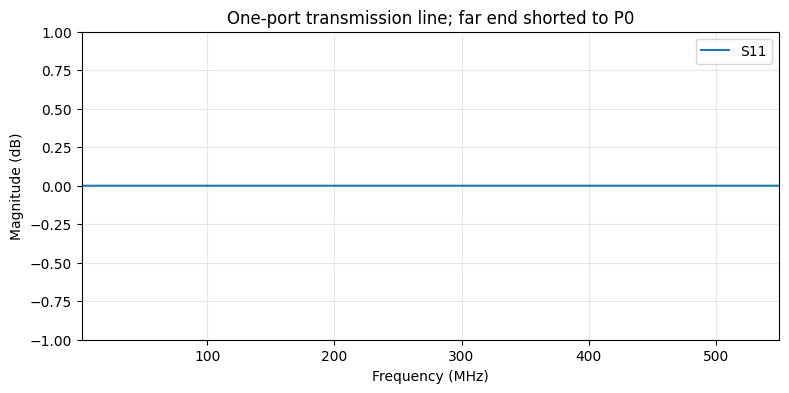

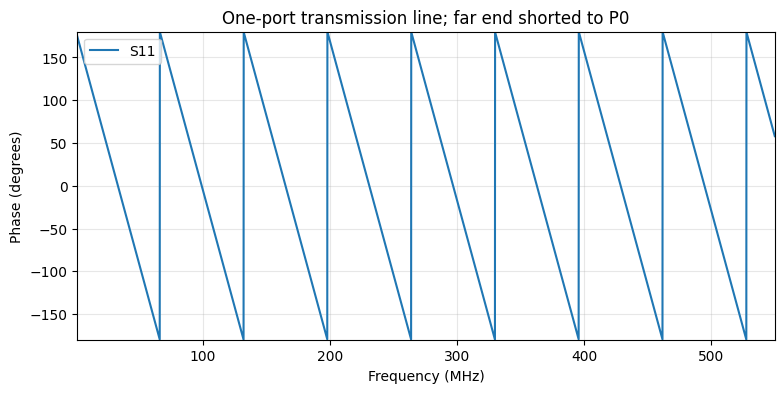

In [16]:
_ = short_circuit.Plot_Sparameter(
    "S11", xlim=Frequency_Limits, ylim=(-1, 1),
)
_ = short_circuit.Plot_Sparameter(
    "S11", phase=True, xlim=Frequency_Limits,
)


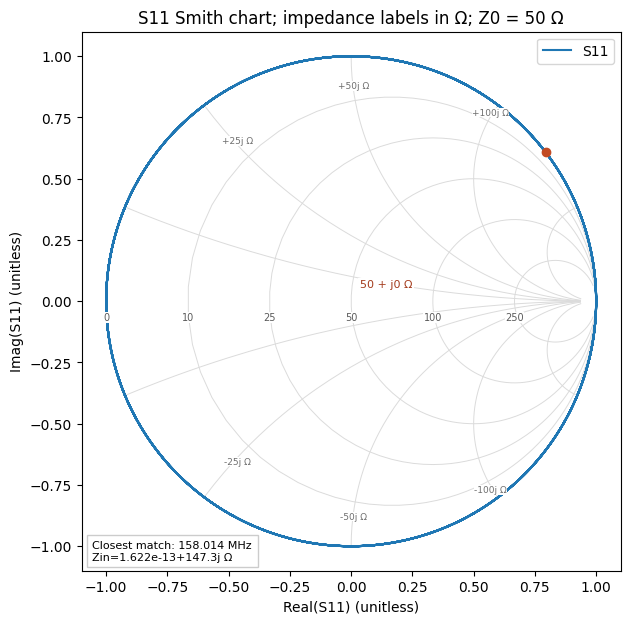

In [17]:
_ = short_circuit.Plot_Smith("S11")


In [18]:
short_panel = short_circuit.Plot_Interactive(
    ["S11"], xlim=Frequency_Limits, ylim=(-1, 1),
    points=Sweep_Points, refine=False,
    markers=(150, 180),
)


## Interpretation

For a lossless line, with characteristic impedance $Z_c$ and electrical length $\theta=2\pi f\ell/v$:

$$Z_{in,open}=-jZ_c\cot\theta,\qquad Z_{in,short}=jZ_c\tan\theta.$$

At one quarter wavelength, an open far end becomes a short at the input, and a shorted far end becomes an open at the input. This is impedance transformation, not a 50-ohm match. With zero loss, both single-port examples have $|S_{11}|=1$ (0 dB), while phase and input reactance change with frequency.

For a two-port line whose characteristic impedance equals the port reference impedance, $S_{11}=S_{22}=0$ and $S_{21}=S_{12}=\exp(-\gamma\ell)$.

Open Component values in each panel to tune its line independently. M1 and M2 show magnitude, phase and input impedance in ohms. On S21/S12 transmission views, input impedance is computed from the corresponding reflection trace. The -3 dB button finds crossings only when they exist; a lossless open/short line's S11 has no absolute -3 dB crossing.

The earlier frequency and S variables are snapshots. Current arrays after tuning are, for example, `open_circuit.frequency` and `open_circuit.s`. Static figures update when their cells are rerun.

Reference: Michael Steer, *Microwave and RF Design II – Transmission Lines*, Section 2.4, [Special Cases of Lossless Terminated Lines](https://eng.libretexts.org/Bookshelves/Electrical_Engineering/Electronics/Microwave_and_RF_Design_II_-_Transmission_Lines_%28Steer%29/02%253A_Transmission_Lines/2.04%253A_Special_Cases_of_Lossless_Terminated_Lines).


## Optional impedance plots and JSON saving

These commands are commented for now. Impedance plots use actual real and imaginary impedance in ohms. At a true open circuit, input impedance tends to infinity; a finite plotting range can hide that divergence. Add loss if you want a finite resistance at a resonance.


In [19]:
# Optional impedance plots:
# two_port_circuit.Plot_Impedance(port=1, xlim=Frequency_Limits)
# open_circuit.Plot_Impedance(port=1, xlim=Frequency_Limits)
# short_circuit.Plot_Impedance(port=1, xlim=Frequency_Limits)

# Save current tuned parameters:
# two_port_circuit.Save_Parameters("Transmission_Line_Two_Port.json")
# open_circuit.Save_Parameters("Transmission_Line_Open.json")
# short_circuit.Save_Parameters("Transmission_Line_Short.json")

# Load a saved circuit:
# open_circuit = RFCircuit.Load_Parameters("Transmission_Line_Open.json")
